In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy.ndimage import gaussian_filter1d as gf1d
import notebooks.PlotClouds as plot_clouds
import pp_model.PPmodel as pr

plt.rcParams['figure.figsize'] = [20,10]
plt.rcParams['figure.dpi'] = 50
plt.rcParams['savefig.dpi'] = 240

plt.rcParams['font.size'] = 30
plt.rcParams['legend.fontsize'] = 'large'

In [3]:
# Set tile width you want to use
tile_width = 8

# Set today's date
Date = np.datetime_as_string(np.datetime64('today'))
# Set experiment number (if you're running numerous different experiments in a given day)
exp_num = '_exp01'
# creates file_ID
file_ID = Date+exp_num+'_TW%s'%(tile_width)
# Import color scheme
Colors = plot_clouds.Colors()

# Find all cloud cycles within both sets

In [4]:
# Import Tile width data set
#set file number
fold_num = 1
file_num = 11
file_num_str = str(file_num).zfill(2)

# Import Tile width data set
nc_H = Dataset(('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' 
                + file_num_str + '_tw8.nc') %fold_num)

#make sure units are in meters
fac = 1000
# Import dimensions
nt,nx,ny = nc_H.variables['Tile Width %s'%(tile_width)].shape
# Define H_all
Index = np.arange(0,nx,tile_width)
# Multiplying by 1000 to change km into meters (og *1 *)
H_all = fac*nc_H.variables['Tile Width %s'%(tile_width)][:,Index,Index]
# define the number of tiles horizontal tiles
nTiles = nx//tile_width 
print(nTiles)

30


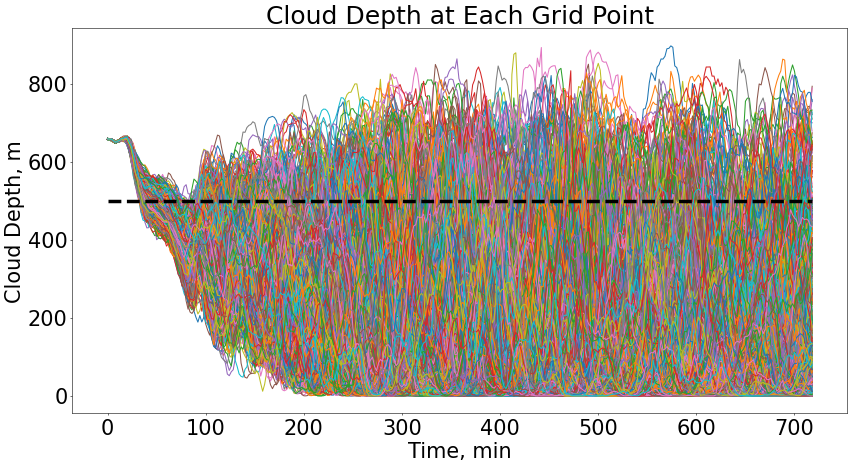

In [5]:
# plot signal
plot_max = 0
space_fac = int(720/len(H_all[:,0,0]))
xaxis = np.arange(0,720, space_fac)
plt.figure()
for kk in range(nTiles):
    for jj in range(nTiles):
        #find maximum
        index_max = np.max(H_all[:,kk,jj])
        if (index_max > plot_max): 
            plot_max = index_max
        plt.plot(xaxis, H_all[:,kk,jj]) #gf1d(H_all[:,kk,jj],5))
        #plt.show()
plot_max = 500
#plt.plot(xaxis, np.zeros(len(xaxis)), '--', color = 'k', linewidth = '5')
plt.plot(xaxis, plot_max*np.ones(len(xaxis)), '--', color = 'k', linewidth = '5')
plt.title('Cloud Depth at Each Grid Point')
plt.xlabel('Time, min')
plt.ylabel('Cloud Depth, m')

plt.show()

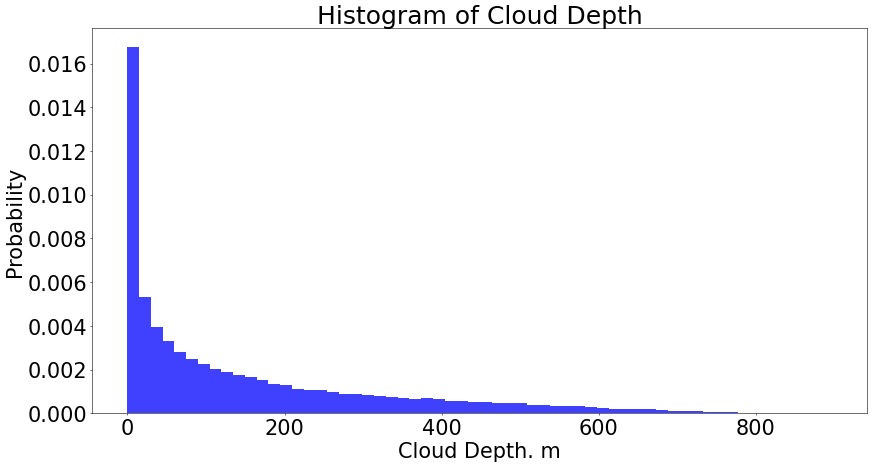

In [6]:
# the histogram of the data
cc = Dataset(('LES/%d/Precip/EMUSCU_snd_0'+ file_num_str +
             '/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc') %fold_num)
CLDLOW = cc.variables['CLDLOW'][:]
spin_up = pr.find_spinup_end(CLDLOW)

n, bins, patches = plt.hist(H_all[spin_up:].flatten(), 
                            60, density=True, facecolor='b', alpha=0.75)

plt.xlabel('Cloud Depth. m')
plt.ylabel('Probability')
plt.title('Histogram of Cloud Depth')
plt.show()

245.0619297159024
348.1249902397394


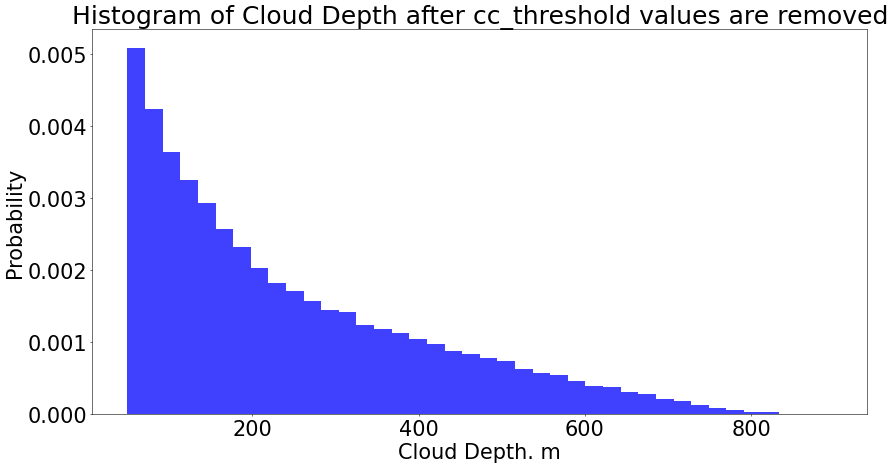

In [7]:
cloud_cover = 0
cc_threshold = 50
count = 0
my_new_H_all = []
for kk in range(nTiles):
    for jj in range(nTiles):
        for ii in range(len(H_all[spin_up:,0,0])):
            if (H_all[spin_up + ii,jj,kk] > cc_threshold): 
                cloud_cover = cloud_cover + H_all[spin_up + ii, jj, kk]
                count = count + 1
                my_new_H_all.append(H_all[spin_up + ii, jj, kk])
                
cc_mean = cloud_cover / count 
print(cc_mean)
prec_thres = np.percentile(my_new_H_all, 75)
print(prec_thres)

n, bins, patches = plt.hist(my_new_H_all, 
                            40, density=True, facecolor='b', alpha=0.75)

plt.xlabel('Cloud Depth. m')
plt.ylabel('Probability')
plt.title('Histogram of Cloud Depth after cc_threshold values are removed')
plt.show()

#look at histogram after the tolerance had been applied
#cycle through cc threshold (try a couple) extract all cycles then get the means and then plot them all to see 
#what the difference is 
#look at cc_threshold for Spence's simulation 

In [9]:
lower_thresh = prec_thres# cloud must start below this depth #keep them the same
upper_thresh = prec_thres # cloud must grow above this depth
sigma = 5       # standard deviation of Gaussian filter for temporal smoother og = 10 min
timeSteptoMin = 30 #og = 60 minutes
time_thresh = 37.5 #minimum length of a cycle (75 minutes)


XYT = []
for kk in range(nTiles):
    for jj in range(nTiles):
        H = gf1d(H_all[spin_up:,kk,jj],sigma)
        minimums = np.where((H[1:-1] < H[0:-2]) * (H[1:-1] < H[2:]))[0] + 1 
        for pp in range(1, len(minimums)): 
            my_next_min = minimums[-pp - 1]
            my_max = np.argmax(H[my_next_min:minimums[-pp]]) + my_next_min
            if(H[minimums[-pp]] < lower_thresh and H[my_next_min] < lower_thresh and 
                H[my_max] > upper_thresh and minimums[-pp] - my_next_min > time_thresh): 
                t_start = spin_up + my_next_min
                t_end = spin_up + minimums[-pp]
                t_mid = spin_up + my_max
                XYT.append([kk,jj,t_start,t_end,t_mid])
            
print(len(XYT))
XYT = np.array(XYT)
#Notes: This needs to be rewritten so that all the local extrame are found and that EVERY
#CYCLE is found in order to be tested and not just finding the first cycle every time

188


/Users/rgjini/opt/anaconda3/envs/clouds/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/rgjini/opt/anaconda3/envs/clouds/lib/python3.13/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


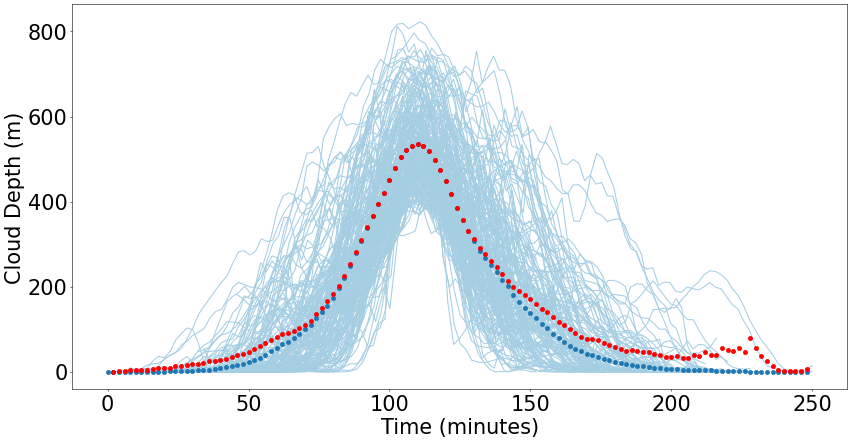

822.500005364418 125


In [10]:
All_clouds = []
for kk in range(len(XYT)):
    x,y,t1,t2,tmid = XYT[kk,:]
    All_clouds.append(H_all[t1:t2,x,y])
    
longest_cloud = np.max(XYT[:,4]-XYT[:,2])+np.max(XYT[:,3]-XYT[:,4])
mid_cloud = np.max(XYT[:,4]-XYT[:,2])
y_extended = np.zeros((longest_cloud,len(XYT)))
for kk in range(len(XYT)):
    x,y,t1,t2,tmid = XYT[kk,:]

    y_extended[mid_cloud-(tmid-t1):mid_cloud,kk]=H_all[t1:tmid,x,y]
    y_extended[mid_cloud:mid_cloud+(t2-tmid),kk]=H_all[tmid:t2,x,y]
    plt.plot(2*np.linspace((mid_cloud-(tmid-t1)),(mid_cloud+t2-tmid),t2-t1),y_extended[mid_cloud-(tmid-t1):mid_cloud+t2-tmid,kk],color=Colors['LES_err'])
plt.plot(2*np.arange(longest_cloud ),np.mean(y_extended,axis=1),'o',color = Colors['LES'])
plt.plot(2*np.arange(longest_cloud ),np.mean(y_extended,axis=1, where = y_extended > 0),'o',color = 'red')
plt.xlabel('Time (minutes)')
plt.ylabel('Cloud Depth (m)')
plt.show()
print(np.max(y_extended),len(y_extended))

# Cov with uniform inflation

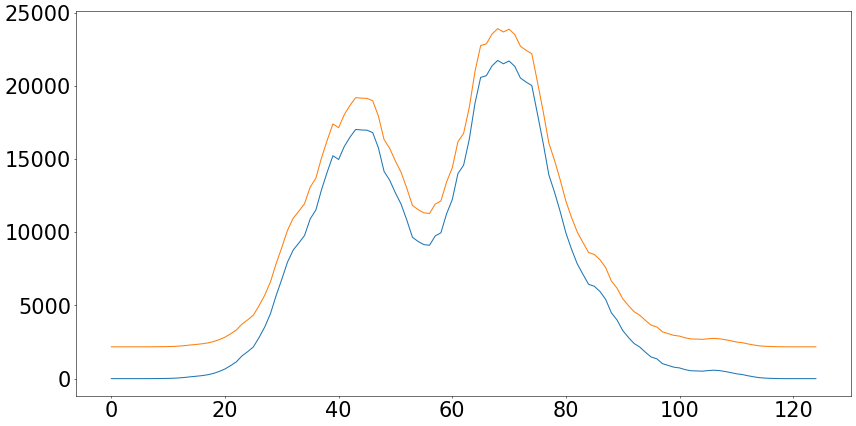

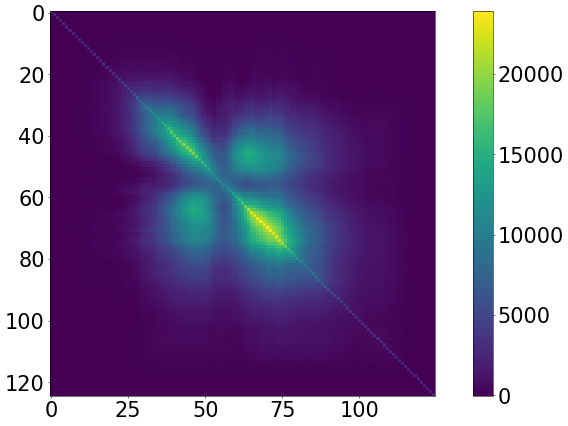

In [12]:
Cov = np.cov(y_extended)

# #calculate diagonal
Cov_diag = np.diagonal(Cov)
# #Calculate the max variance value
max_Cov_diag = np.amax(Cov_diag)
percentage = 0.1
CCov = Cov + percentage*max_Cov_diag*np.identity(len(Cov))

plt.plot(np.diag(Cov))
plt.plot(np.diag(CCov))
plt.show()

tmp = np.abs(Cov).max()
plt.imshow(CCov,cmap = 'viridis')#,vmin=-tmp,vmax=tmp)
plt.colorbar()
plt.show()
